In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.seasonal import seasonal_decompose

In [39]:
# Load cleaned stock prices dataset
df = pd.read_csv("cleaned_stock_prices.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by symbol and date
df = df.sort_values(by=["symbol", "date"])

# Display first few rows
df.head()

,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
1,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
2,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
3,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
4,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


In [40]:
# Select one stock symbol for analysis
selected_symbol = "AAPL"

# Filter dataset for selected stock
stock_data = df[df["symbol"] == selected_symbol].copy()

# Set date as the index
stock_data = stock_data.set_index("date")

# Display first few rows
stock_data.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


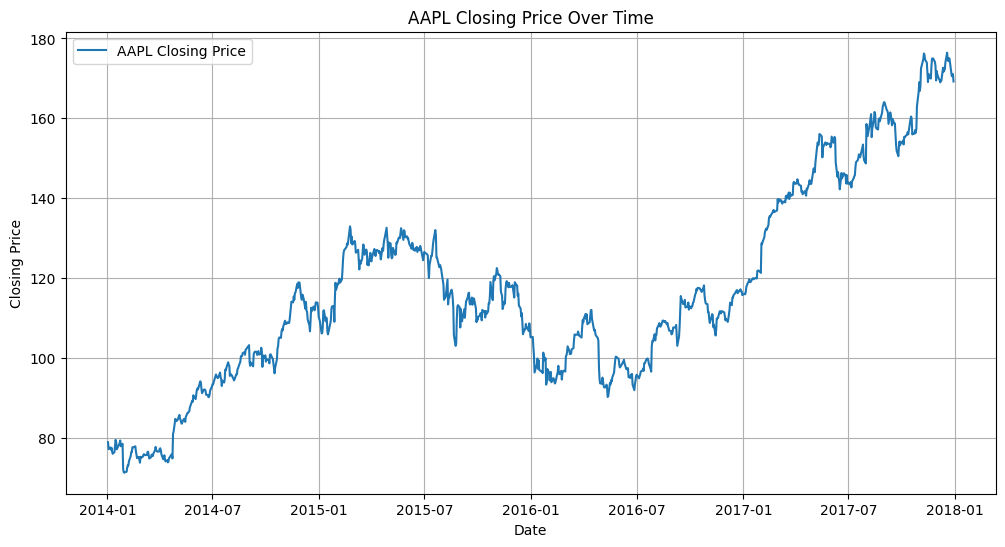

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(stock_data.index, stock_data["close"], label=f"{selected_symbol} Closing Price")

plt.title(f"{selected_symbol} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

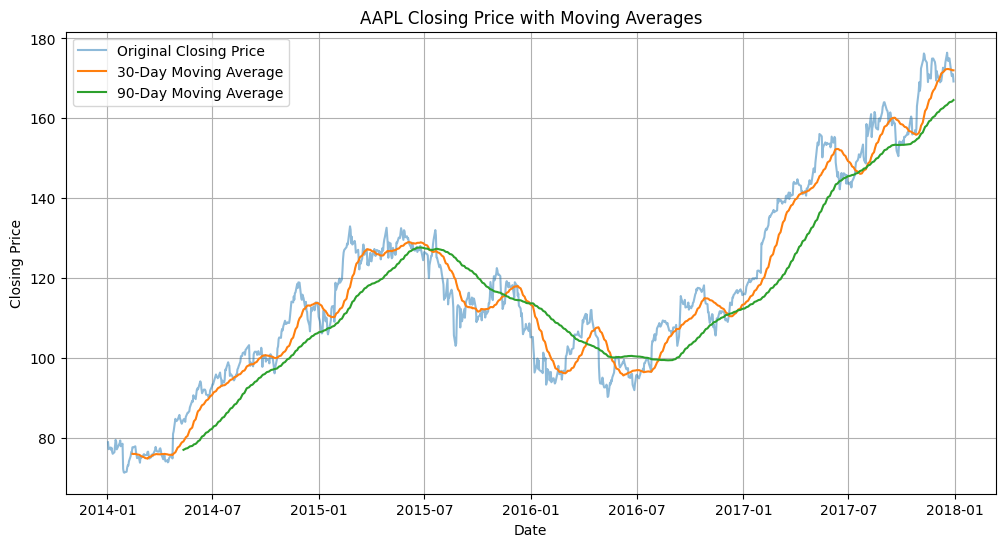

In [42]:
# Calculate 30-day and 90-day moving averages
stock_data["MA_30"] = stock_data["close"].rolling(window=30).mean()
stock_data["MA_90"] = stock_data["close"].rolling(window=90).mean()

plt.figure(figsize=(12, 6))

plt.plot(stock_data.index, stock_data["close"], label="Original Closing Price", alpha=0.5)
plt.plot(stock_data.index, stock_data["MA_30"], label="30-Day Moving Average")
plt.plot(stock_data.index, stock_data["MA_90"], label="90-Day Moving Average")

plt.title(f"{selected_symbol} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
# Convert daily closing prices into monthly average closing prices
monthly_close = stock_data["close"].resample("ME").mean()

# Display first few values
monthly_close.head()

date
2014-01-31    76.777876
2014-02-28    75.225637
2014-03-31    76.173400
2014-04-30    77.296243
2014-05-31    86.170752
Freq: ME, Name: close, dtype: float64

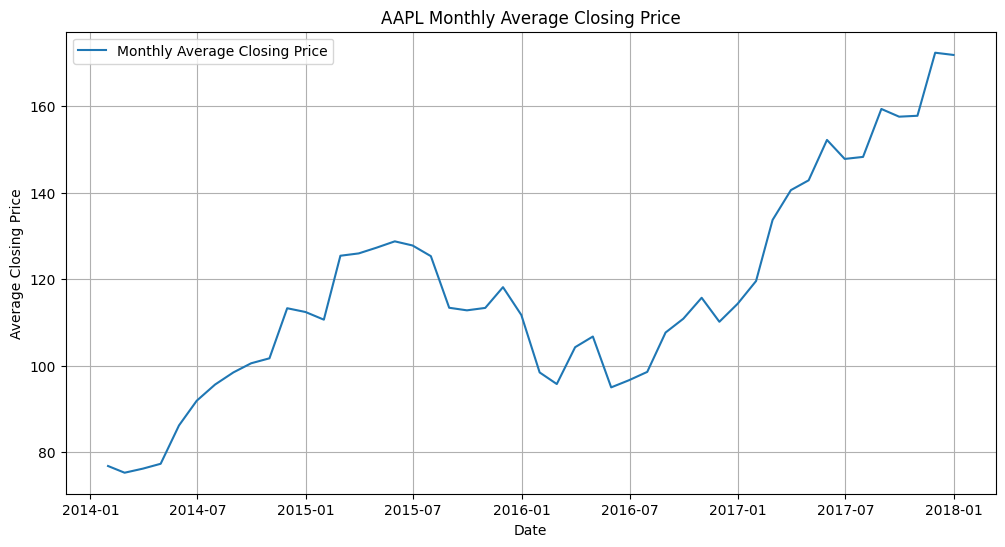

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_close.index, monthly_close.values, label="Monthly Average Closing Price")

plt.title(f"{selected_symbol} Monthly Average Closing Price")
plt.xlabel("Date")
plt.ylabel("Average Closing Price")
plt.legend()
plt.grid(True)

plt.show()

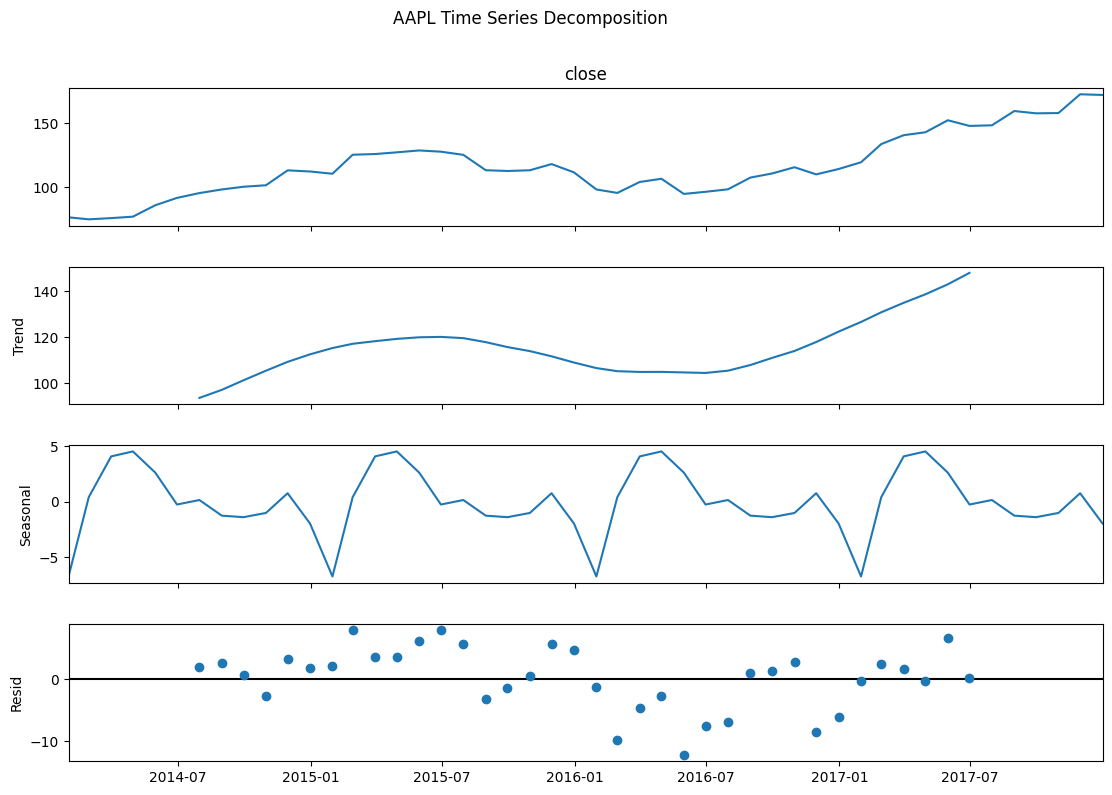

In [45]:
# Decompose the monthly time series
decomposition = seasonal_decompose(
    monthly_close,
    model="additive",
    period=12
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.suptitle(f"{selected_symbol} Time Series Decomposition", y=1.02)
plt.show()

In [46]:
# Create folder for time-series visualizations
os.makedirs("time_series_visualizations", exist_ok=True)

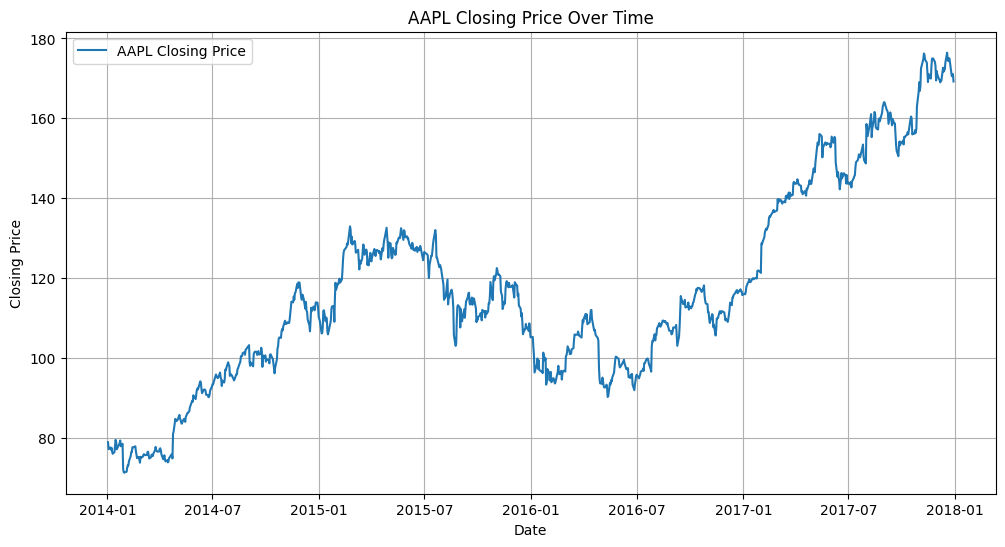

In [47]:
# Save original closing price plot
plt.figure(figsize=(12, 6))

plt.plot(stock_data.index, stock_data["close"], label=f"{selected_symbol} Closing Price")

plt.title(f"{selected_symbol} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.savefig("time_series_visualizations/closing_price_over_time.png", bbox_inches="tight")
plt.show()

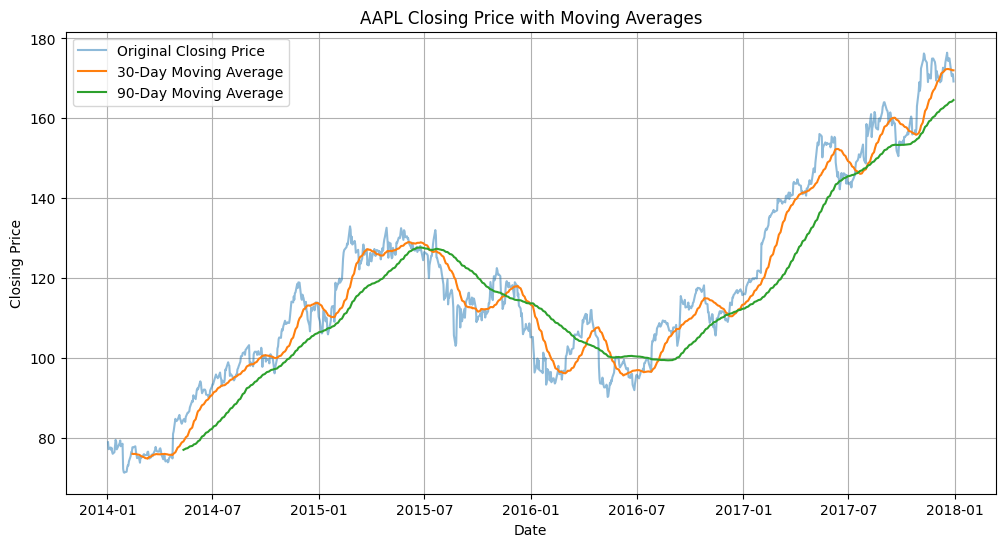

In [48]:
# Save moving average plot
plt.figure(figsize=(12, 6))

plt.plot(stock_data.index, stock_data["close"], label="Original Closing Price", alpha=0.5)
plt.plot(stock_data.index, stock_data["MA_30"], label="30-Day Moving Average")
plt.plot(stock_data.index, stock_data["MA_90"], label="90-Day Moving Average")

plt.title(f"{selected_symbol} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.savefig("time_series_visualizations/moving_average_smoothing.png", bbox_inches="tight")
plt.show()

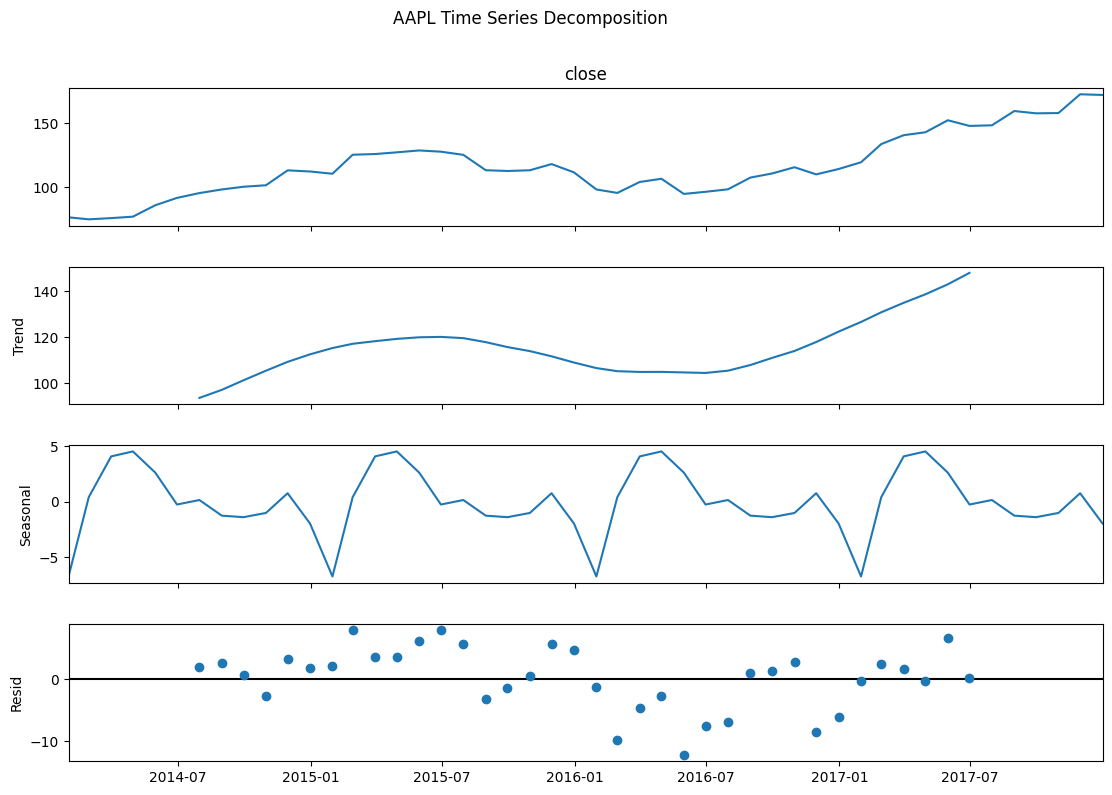

In [49]:
# Save decomposition plot
fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.suptitle(f"{selected_symbol} Time Series Decomposition", y=1.02)

plt.savefig("time_series_visualizations/time_series_decomposition.png", bbox_inches="tight")
plt.show()

## Level 2 Task 2: Time Series Analysis Summary

For this task, I performed time-series analysis using the cleaned stock prices dataset. I selected AAPL as the stock symbol for analysis and used the closing price as the main time-series variable.

First, I plotted the original closing price over time to identify the general price movement. The line chart showed how the stock price changed across the dataset period.

Next, I applied moving average smoothing using 30-day and 90-day moving averages. The moving averages helped reduce short-term fluctuations and made the overall trend easier to observe.

The data was then resampled into monthly average closing prices to create a regular time series. I used statsmodels to decompose the monthly series into trend, seasonal, and residual components. The trend component showed the long-term movement in the stock price, the seasonal component showed repeating yearly patterns, and the residual component showed random variation not explained by the trend or seasonality.

The results show that stock prices can be analysed over time to identify trends and patterns. The moving average and decomposition methods made it easier to understand the underlying behaviour of the time series.